In [1]:
#!pip install scipy numpy sympy matplotlib pandas

In [2]:

from scipy.signal import savgol_filter
import sympy as sp
import numpy as np
from scipy.interpolate import interp1d
from scipy.interpolate import UnivariateSpline
from IPython.display import display, Markdown

def make_smooth_K(lam_data, k_values, window=51, poly=3, spline_smooth=1e-4):
    """
    Returns a smoothed callable K(lambda).

    Parameters
    ----------
    lam_data : 1-D array  - affine parameter samples from DATA_CARTER.dat
    k_values : 1-D array  – Carter constant samples
    window   : int        – Savitzky-Golay window length (must be odd, > poly)
    poly     : int        – SG polynomial order
    spline_smooth : float – UnivariateSpline smoothing factor for the residual
    """
    window = window if window % 2 == 1 else window + 1
    k_sg   = savgol_filter(k_values, window_length=window, polyorder=poly)
    return UnivariateSpline(lam_data, k_sg, s=spline_smooth, ext='const')

data_k = np.loadtxt('DATA_CARTER.dat')
lam_data = data_k[:, 0]
k_values = data_k[:, 1]
get_K = make_smooth_K(lam_data, k_values, window=51, poly=3)
print(lam_data[-1])

r, theta, E, Lz, a, epsilon, kappa = sp.symbols('r theta E L_z a epsilon kappa')
M = 1.0

Delta_s, Sigma_s, H1_s, H2_s = sp.symbols('Delta Sigma H_1 H_2')

Delta_math = r**2 - 2*M*r + a**2
Sigma_math = r**2 + a**2 * sp.cos(theta)**2
H1_math = epsilon * (Lz - 2*a*E)
H2_math = (epsilon**2 / (8*Sigma_s)) * (-4*a**2 * Delta_s + (5*a**4 + r**4 +2*a**2 *r**2 - 8*M*a**2*r)*sp.sin(theta)**2 - a**2*Delta_s*sp.sin(theta)**4)

#Shorthand symbols for display
V1_disp = (E*(r**2 + a**2) - a*Lz)**2 - Delta_s * (kappa + r**2) + Delta_s * r**2 * H1_s - 2*Delta_s * r**2 * H2_s
V2_disp = (1/sp.sin(theta)**2)*((kappa - (Lz - a*E)**2)*sp.sin(theta)**2 - (Lz*sp.cos(theta))**2 + (a*E*sp.cos(theta)*sp.sin(theta))**2 - (a*sp.cos(theta)*sp.sin(theta))**2 - (a*sp.cos(theta)*sp.sin(theta))**2 * H1_s - 2*(a*sp.cos(theta)*sp.sin(theta))**2 * H2_s)

#Substitute expressions
H2_full = H2_math.subs({Delta_s: Delta_math, Sigma_s: Sigma_math})
V1_full = V1_disp.subs({Delta_s: Delta_math, H1_s: H1_math, H2_s: H2_full})
V2_full = V2_disp.subs({H1_s: H1_math, H2_s: H2_full})

#Full function for numerical use

h2_full_calc = sp.lambdify((r, theta, E, Lz, a, kappa, epsilon), H2_full, 'numpy')
rhs_potentials = sp.lambdify((r, theta, E, Lz, a, kappa, epsilon), [V1_full, V2_full], 'numpy')



display(Markdown("### Symbolic Definitions"))
display_list = [
    ("V_1", V1_disp),
    ("V_2", V2_disp),
    ("H_1", H1_math),
    ("H_2", H2_math),
    ("\\Delta", Delta_math),
    ("\\Sigma", Sigma_math)
]

size_command = r"\Large" 

for label, expr in display_list:
    eq = sp.Eq(sp.Symbol(label), expr)
    
    latex_str = sp.latex(eq)
    
    display(Markdown(f"$${size_command} {latex_str}$$"))
    


1009.998


### Symbolic Definitions

$$\Large V_{1} = \Delta H_{1} r^{2} - 2 \Delta H_{2} r^{2} - \Delta \left(\kappa + r^{2}\right) + \left(E \left(a^{2} + r^{2}\right) - L_{z} a\right)^{2}$$

$$\Large V_{2} = \frac{E^{2} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - H_{1} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - 2 H_{2} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - L_{z}^{2} \cos^{2}{\left(\theta \right)} - a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} + \left(\kappa - \left(- E a + L_{z}\right)^{2}\right) \sin^{2}{\left(\theta \right)}}{\sin^{2}{\left(\theta \right)}}$$

$$\Large H_{1} = \epsilon \left(- 2 E a + L_{z}\right)$$

$$\Large H_{2} = \frac{\epsilon^{2} \left(- \Delta a^{2} \sin^{4}{\left(\theta \right)} - 4 \Delta a^{2} + \left(5 a^{4} + 2 a^{2} r^{2} - 8.0 a^{2} r + r^{4}\right) \sin^{2}{\left(\theta \right)}\right)}{8 \Sigma}$$

$$\Large \Delta = a^{2} + r^{2} - 2.0 r$$

$$\Large \Sigma = a^{2} \cos^{2}{\left(\theta \right)} + r^{2}$$

In [3]:
import sympy as sp
from IPython.display import display, Markdown

# 1. Define standard variables and canonical momenta
r, theta, E, L_z, a, M, P_r, P_theta, epsilon = sp.symbols('r theta E L_z a M P_r P_theta epsilon')

# Define Delta and Sigma as abstract symbols for clean LaTeX display
Delta_s, Sigma_s = sp.symbols('Delta Sigma')

# Exact mathematical definitions (for later substitution/lambdify)
Delta_math = r**2 - 2*M*r + a**2
Sigma_math = r**2 + a**2 * sp.cos(theta)**2

# 2. Metric Components (Using the abstract Delta symbol)
T_tt = -(r**2 + a**2)**2 / Delta_s
T_tphi = -a*(r**2 + a**2) / Delta_s
T_phiphi = -a**2 / Delta_s
T_rr = Delta_s

Theta_tt = a**2 * sp.sin(theta)**2
Theta_tphi = a
Theta_phiphi = 1 / sp.sin(theta)**2 


Theta_thetatheta = 1

# 3. Base Hamiltonian Segments (H0)
H0_r = T_rr * P_r**2 + T_tt * E**2 - 2 * T_tphi * E * L_z + T_phiphi * L_z**2
H0_theta = Theta_thetatheta * P_theta**2 + Theta_tt * E**2 - 2 * Theta_tphi * E * L_z + Theta_phiphi * L_z**2

H0 = (H0_r + H0_theta) / (Sigma_s)

# 4. Perturbation Segments (H1, H2)
H1 = epsilon * (L_z - 2*a*E)

H2_term1 = -4 * a**2 * Delta_s
H2_term2 = (5*a**4 + r**4 + 2*a**2 * r**2 - 8*M*a**2 * r) * sp.sin(theta)**2
H2_term3 = -a**2 * Delta_s * sp.sin(theta)**4

H2 = (epsilon**2 / (8 * Sigma_s)) * (H2_term1 + H2_term2 + H2_term3)

# 5. Total Hamiltonian
H_total = (1/2)*(H0 + H1 + H2)

# Full substitued version for numerical integration later
H_full_numeric = H_total.subs({Delta_s: Delta_math, Sigma_s: Sigma_math})

# --- DISPLAY HELPER ---
def show_eq(name, expr):
    eq = sp.Eq(sp.Symbol(name), expr)
    display(Markdown(f"$$Large {sp.latex(eq)}$$"))

# Render output in Jupyter
display(Markdown("### Unperturbed Hamiltonian ($H_0$)"))
show_eq("H_0^r", sp.simplify(H0_r))
show_eq("H_0^theta", sp.simplify(H0_theta))
show_eq("H_0", H0)

display(Markdown("### Perturbations ($H_1, H_2$)"))
show_eq("H_1", H1)
show_eq("H_2", H2)

display(Markdown("### Total Hamiltonian ($H$)"))
show_eq("H", H_total)

calc_H = sp.lambdify(
    (r, theta, P_r, P_theta, E, L_z, a, M, epsilon), 
    H_full_numeric, 
    'numpy'
)


### Unperturbed Hamiltonian ($H_0$)

$$Large H^{r}_{0} = \frac{\Delta^{2} P_{r}^{2} - E^{2} \left(a^{2} + r^{2}\right)^{2} + 2 E L_{z} a \left(a^{2} + r^{2}\right) - L_{z}^{2} a^{2}}{\Delta}$$

$$Large H^{\theta}_{0} = E^{2} a^{2} \sin^{2}{\left(\theta \right)} - 2 E L_{z} a + \frac{L_{z}^{2}}{\sin^{2}{\left(\theta \right)}} + P_{\theta}^{2}$$

$$Large H_{0} = \frac{\Delta P_{r}^{2} + E^{2} a^{2} \sin^{2}{\left(\theta \right)} - 2 E L_{z} a + \frac{L_{z}^{2}}{\sin^{2}{\left(\theta \right)}} + P_{\theta}^{2} - \frac{E^{2} \left(a^{2} + r^{2}\right)^{2}}{\Delta} + \frac{2 E L_{z} a \left(a^{2} + r^{2}\right)}{\Delta} - \frac{L_{z}^{2} a^{2}}{\Delta}}{\Sigma}$$

### Perturbations ($H_1, H_2$)

$$Large H_{1} = \epsilon \left(- 2 E a + L_{z}\right)$$

$$Large H_{2} = \frac{\epsilon^{2} \left(- \Delta a^{2} \sin^{4}{\left(\theta \right)} - 4 \Delta a^{2} + \left(- 8 M a^{2} r + 5 a^{4} + 2 a^{2} r^{2} + r^{4}\right) \sin^{2}{\left(\theta \right)}\right)}{8 \Sigma}$$

### Total Hamiltonian ($H$)

$$Large H = 0.5 \epsilon \left(- 2 E a + L_{z}\right) + \frac{0.0625 \epsilon^{2} \left(- \Delta a^{2} \sin^{4}{\left(\theta \right)} - 4 \Delta a^{2} + \left(- 8 M a^{2} r + 5 a^{4} + 2 a^{2} r^{2} + r^{4}\right) \sin^{2}{\left(\theta \right)}\right)}{\Sigma} + \frac{0.5 \left(\Delta P_{r}^{2} + E^{2} a^{2} \sin^{2}{\left(\theta \right)} - 2 E L_{z} a + \frac{L_{z}^{2}}{\sin^{2}{\left(\theta \right)}} + P_{\theta}^{2} - \frac{E^{2} \left(a^{2} + r^{2}\right)^{2}}{\Delta} + \frac{2 E L_{z} a \left(a^{2} + r^{2}\right)}{\Delta} - \frac{L_{z}^{2} a^{2}}{\Delta}\right)}{\Sigma}$$

In [4]:
E, Lz, a, epsilon = 0.98, 3.3, 0.5, -0.001
lam, r, theta = 2.642455 , 40.324777000000000,	1.5722110000000000
test_state = (r, theta, E, Lz, a, get_K(lam), epsilon)
v1 = rhs_potentials(*test_state)[0]
print(v1)

0.5573385981842875


In [5]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

def geodesic_integrator(initial_state, initial_signs, lam_range, params, epsilon, proxy_eps, rtol, atol):
    E_val, Lz_val, a_val = params
    eps_val = epsilon
    curr_lam, end_lam = lam_range
    curr_state = np.array(initial_state, dtype=float)
    proxy_eps_th = 2.8e-9
    def odes(t, y, E_v, Lz_v, a_v, eps_v):
        r_c, th_c = y
        k_c = get_K(t)
        v1, v2 = rhs_potentials(r_c, th_c, E_v, Lz_v, a_v, k_c, eps_v)
        
        dr = np.sqrt(np.maximum(v1, proxy_eps)) * odes.sign_r
        dt = np.sqrt(np.maximum(v2, proxy_eps_th)) * odes.sign_th
        return [dr, dt]

    odes.sign_r, odes.sign_th = initial_signs
    
    def event_v1(t, y, *args):
        v1, _ = rhs_potentials(y[0], y[1], *args[:3], get_K(t), args[3])
        return v1 - proxy_eps
    event_v1.terminal, event_v1.direction = True, -1

    def event_v2(t, y, *args):
        _, v2 = rhs_potentials(y[0], y[1], *args[:3], get_K(t), args[3])
        return v2 - proxy_eps_th
    event_v2.terminal, event_v2.direction = True, -1

    def event_horizon(t, y, *args): return y[0] - 2.001
    event_horizon.terminal = True

    def event_r_max(t, y, *args): return y[0] - 100.0
    event_r_max.terminal = True

    def event_theta_bounds(t, y, *args):
        return (y[1] - 0.001) * (np.pi - 0.001 - y[1])
    event_theta_bounds.terminal = True

    all_r, all_th, all_l, all_vr, all_vth = [], [], [], [], []

    loop_log = []

    while curr_lam < end_lam:
        sol = solve_ivp(
            odes, (curr_lam, end_lam), curr_state,
            args=(E_val, Lz_val, a_val, eps_val),
            events=[event_v1, event_v2, event_horizon, event_r_max, event_theta_bounds],
            rtol=rtol, atol=atol, method='DOP853', dense_output=True
        )  

        # --- ADDED: Calculate exact velocities for this integrated segment ---
        r_seg = sol.y[0]
        th_seg = sol.y[1]
        t_seg = sol.t
        
        # Recalculate potentials for the segment using the exact interpolated K
        v1_seg, v2_seg = rhs_potentials(r_seg, th_seg, E_val, Lz_val, a_val, get_K(t_seg), eps_val)
        
        # Apply the exact signs that were active during this step
        vr_seg = np.sqrt(np.maximum(v1_seg, proxy_eps)) * odes.sign_r
        vth_seg = np.sqrt(np.maximum(v2_seg, proxy_eps)) * odes.sign_th

        # Aggregate valid results
        if not all_l:
            all_r.extend(r_seg)
            all_th.extend(th_seg)
            all_l.extend(t_seg)
    
            all_vr.extend(vr_seg)      
            all_vth.extend(vth_seg)    
        else:
            all_r.extend(r_seg[1:])
            all_th.extend(th_seg[1:])
            all_l.extend(t_seg[1:])

            all_vr.extend(vr_seg[1:])      
            all_vth.extend(vth_seg[1:])    
        
        curr_state = sol.y[:, -1]
        curr_lam = sol.t[-1]

        loop_log.append({
            'lambda': curr_lam,
            'state': curr_state.tolist(),
            'events': [len(e) for e in sol.t_events],
            'success': sol.success,
            'message': sol.message
        })

        if sol.t_events[2].size > 0:
            print(f"Halt: Horizon reached at lambda={curr_lam:.2f}")
            break
        if sol.t_events[3].size > 0 or sol.t_events[4].size > 0:
            print(f"Halt: Boundary reached at lambda={curr_lam:.2f}")
            break

        # Normal momentum sign flip and small nudge at detected turning points
        if sol.t_events[0].size > 0:
            odes.sign_r *= -1
            curr_state[0] += odes.sign_r * 1e-8
            curr_lam += np.abs((all_l[-1] - all_l[-2])/(all_r[-1] - all_r[-2]))*1e-8
        if sol.t_events[1].size > 0:
            odes.sign_th *= -1
            curr_state[1] += odes.sign_th * 1e-8
            curr_lam += np.abs((all_l[-1] - all_l[-2])/(all_th[-1] - all_th[-2]))*1e-8

    return {
        'r': np.array(all_r),
        'theta': np.array(all_th),
        'lambda': np.array(all_l),
        'vr': np.array(all_vr),        
        'vtheta': np.array(all_vth),   
        'log': pd.DataFrame(loop_log)
    }

In [6]:
#Config and exec
init_state = [40.323, np.pi/2]  #(r_initial, theta_initial)
phys_params = (0.98, 3.3, 0.5)  #(E, Lz, a)
eps = -0.001

results = geodesic_integrator(
    init_state,
    initial_signs=[-1, 1],
    lam_range=[0, 200],
    params=phys_params,
    epsilon=eps,
    proxy_eps=2.8e-9,
    rtol = 2.8e-9,
    atol = 3.5e-10
)

In [7]:
# Data Processing 
results['log'].to_csv("loop_log.csv", index=False)


tol = 1e-14
diffs = np.diff(results['lambda'])

mask = np.append(diffs > tol, [True])

print(mask)

lam_clean = results['lambda'][mask]
r_clean = results['r'][mask]
th_clean = results['theta'][mask]
vr_clean = results['vr'][mask]
vth_clean = results['vtheta'][mask]

df = pd.DataFrame({
    'lambda': lam_clean,
    'r': r_clean,
    'theta': th_clean,
    'vr': vr_clean,
    'vth': vth_clean
})

df.to_csv('data.csv', index=False)

[ True  True  True ...  True  True  True]


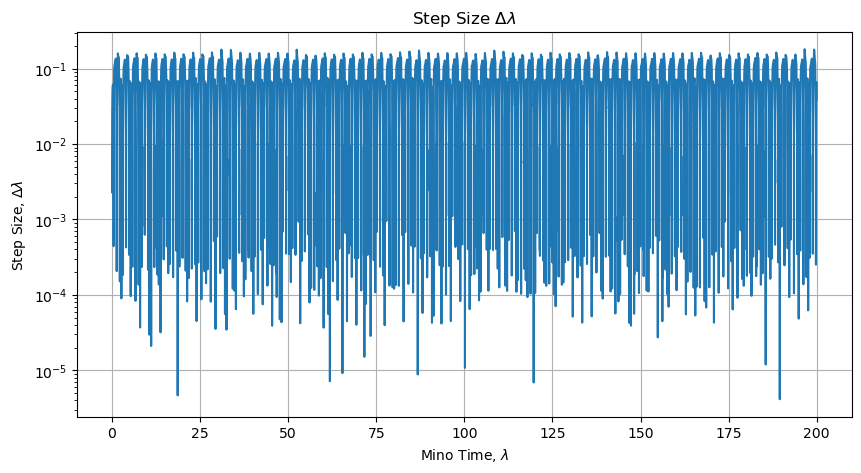

In [8]:
#Step Size Calculations and Plot
delta_lam = []
for i in range(1, len(results['lambda'])):
    delta_lam.append(results['lambda'][i] - results['lambda'][i-1])

plt.figure(figsize=(10, 5))    
plt.semilogy(results['lambda'][:-1], delta_lam)
plt.ylabel(r'Step Size, $\Delta\lambda$')
plt.xlabel(r'Mino Time, $\lambda$')
plt.title(r'Step Size $\Delta\lambda$')
plt.grid(True)

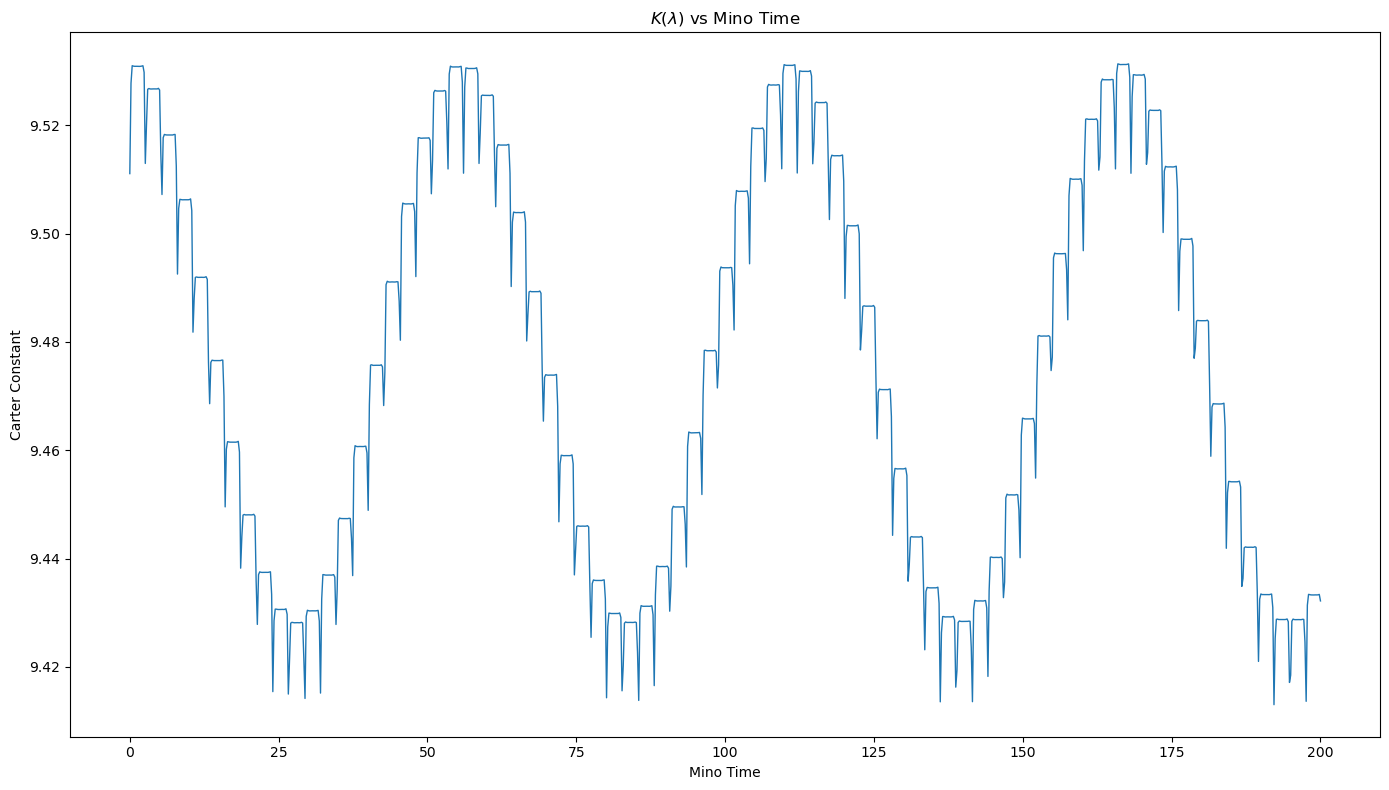

9.476428544804424
258.724297403709


In [24]:
#Carter Constant Info
lams = np.linspace(0, 200, 1000)
K = get_K((lams))

plt.figure(figsize=(14,8))
plt.plot(lams, K, linewidth=1)
plt.xlabel('Mino Time')
plt.ylabel('Carter Constant')
plt.title(r'$K(\lambda)$ vs Mino Time')
#plt.grid(True)
plt.tight_layout()
plt.show()
print(np.mean(K))

print(lam_data[-1])

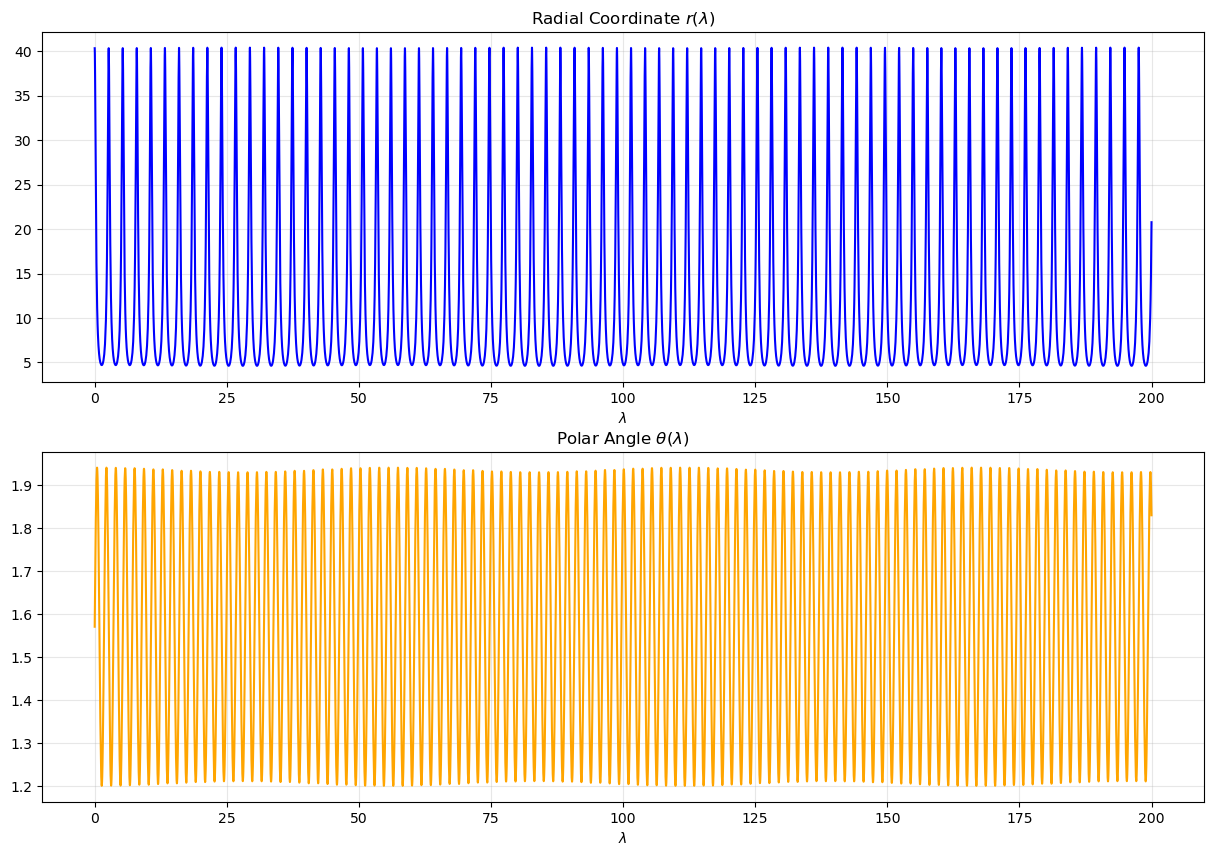

Mean r Error =  0.002515769967115638
Max r Error =  0.011271845718404576
Mean theta Error =  0.0010655402649727825
Max theta Error =  0.004942280952943411


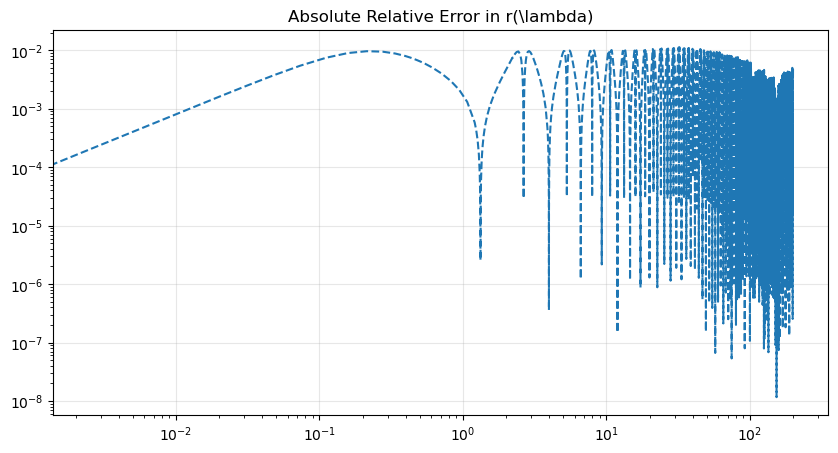

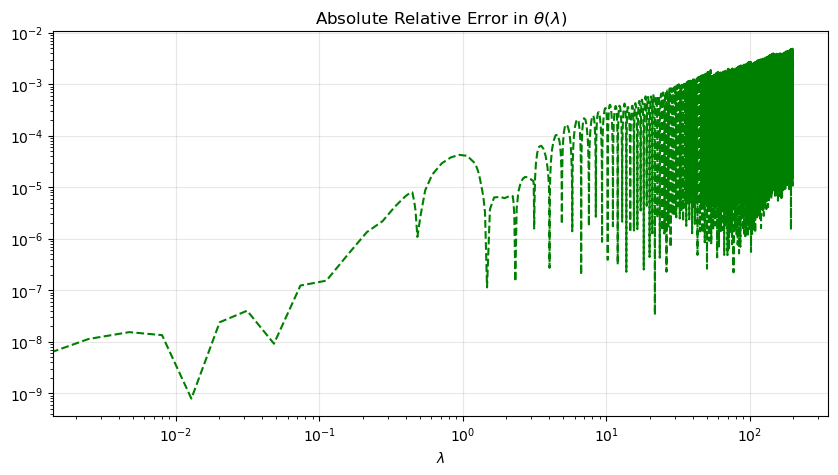

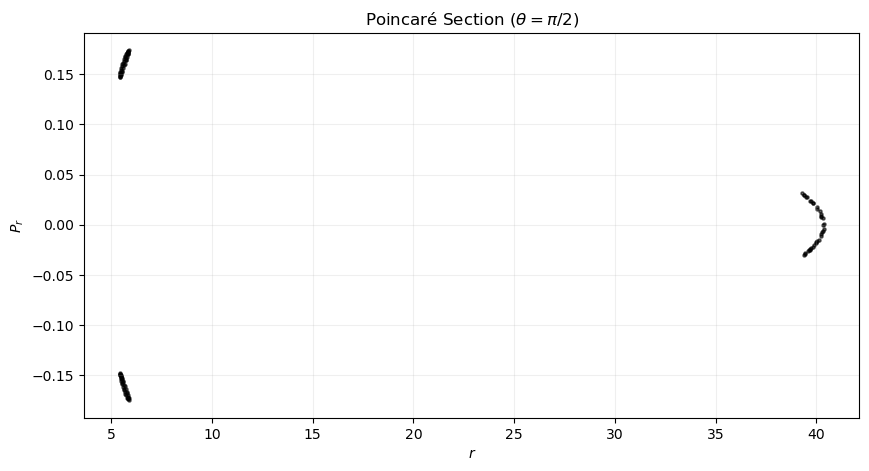

In [10]:
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

r_arr = df['r']
th_arr = df['theta']
Delta = r_arr**2 - 2*r_arr + a**2
Sigma = r_arr**2 + a**2 * np.cos(th_arr)**2
lam_arr = df['lambda']
vth_arr = df['vth']
pth_arr = vth_arr
pr_arr = (1/Sigma)*df['vr']

data_r = np.loadtxt('Neal.dat')
lam_data = data_r[:, 0]
r_values = data_r[:, 1]
get_R = CubicSpline(lam_data, r_values)
#vr_arr = np.sqrt(np.maximum(0, v1_vals))


data_th = np.loadtxt('Neal_theta.dat')
th_values = data_th[:, 1]
get_th = CubicSpline(lam_data, th_values)

r_interp = get_R(lam_arr)
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
ax1.plot(lam_arr, r_arr, color='blue')
#ax1.plot(lam_arr, r_interp, color='green', linestyle='--')
ax1.set_title(r"Radial Coordinate $r(\lambda)$")
ax1.set_xlabel(r"$\lambda$")
ax1.grid(True, alpha=0.3)
#ax1.set_xlim(400, 500)

th_interp = get_th(lam_arr)
#ax2.plot(lam_arr, th_interp, color='blue', linestyle='--')
ax2.plot(lam_arr, th_arr, color='orange')
ax2.set_title(r"Polar Angle $\theta(\lambda)$")
ax2.set_xlabel(r"$\lambda$")
ax2.grid(True, alpha=0.3)
#ax2.set_xlim(400, 500)
plt.show()

error_r = np.abs(r_interp - r_arr)/r_arr
error_th = np.abs(th_interp - th_arr)/th_arr

plt.figure(figsize=(10, 5))
plt.plot(lam_arr, error_r, linestyle = '--')
#plt.plot(lam_arr, error_th, linestyle = '--', color = 'red')
plt.title(r"Absolute Relative Error in r(\lambda)")
plt.yscale('log')
plt.xscale('log')
#plt.xlim(100, 200)
plt.grid(True, alpha=0.3)
print(f"Mean r Error = ", np.mean(error_r))
print(f"Max r Error = ", np.max(error_r))

plt.figure(figsize=(10,5))
plt.loglog(lam_arr, error_th, color='green', linestyle='--')
plt.title(r'Absolute Relative Error in $\theta(\lambda)$')
plt.xlabel(r'$\lambda$')
plt.grid(True, alpha =0.3)
print(f"Mean theta Error = ", np.mean(error_th))
print(f"Max theta Error = ", np.max(error_th))


import numpy as np
from scipy.optimize import brentq
from scipy.interpolate import CubicSpline

def get_precise_crossings(lam_arr, th_arr, r_arr, pr_arr, target_th=np.pi/2):
    """
    Finds exact crossings by finding roots of the function 
    f(lambda) = theta(lambda) - pi/2.
    """
    # 1. We must clean duplicate timestamps first
    mask = np.concatenate(([True], np.diff(lam_arr) > 1e-13))
    t_c, th_c, r_c, pr_c = lam_arr[mask], th_arr[mask], r_arr[mask], pr_arr[mask]

    # 2. Cubic splines provide a smooth th(lam) and th'(lam)
    th_spline = CubicSpline(t_c, th_c)
    r_spline = CubicSpline(t_c, r_c)
    pr_spline = CubicSpline(t_c, pr_c) # If pr is canonical
    dth_spline = th_spline.derivative()

    p_r_exact = []
    p_pr_exact = []
    p_lam_exact = []
    
    # 3. Iterate through intervals where crossings occurred
    for i in range(len(t_c) - 1):
        if (target_th - th_c[i]) * (target_th - th_c[i+1]) < 0:
            
            # Root-finder calculates the exact lambda_cross on the smooth spline
            # f(t) = target_th - spline(t)
            lam_cross = brentq(lambda t: target_th - th_spline(t), t_c[i], t_c[i+1])

            # 4. We only keep the crossing in one direction (descending node)
            if dth_spline(lam_cross) > 0:
                p_r_exact.append(r_spline(lam_cross))
                p_pr_exact.append(pr_spline(lam_cross))
                p_lam_exact.append(lam_cross)
                
    return np.array(p_r_exact), np.array(p_pr_exact), np.array(p_lam_exact)

p_r, p_pr, p_lam = get_precise_crossings(lam_arr, th_arr, r_arr, pr_arr)

plt.figure(figsize=(10, 5))
plt.scatter(p_r, p_pr, s=5, color='black', alpha=0.6)
plt.title(r"Poincaré Section ($\theta = \pi/2$)")
plt.xlabel(r"$r$")
plt.ylabel(r"$P_r$")
plt.grid(True, alpha=0.2)
plt.show()


112


Text(0.5, 1.0, 'pr vs Mino time of crossings')

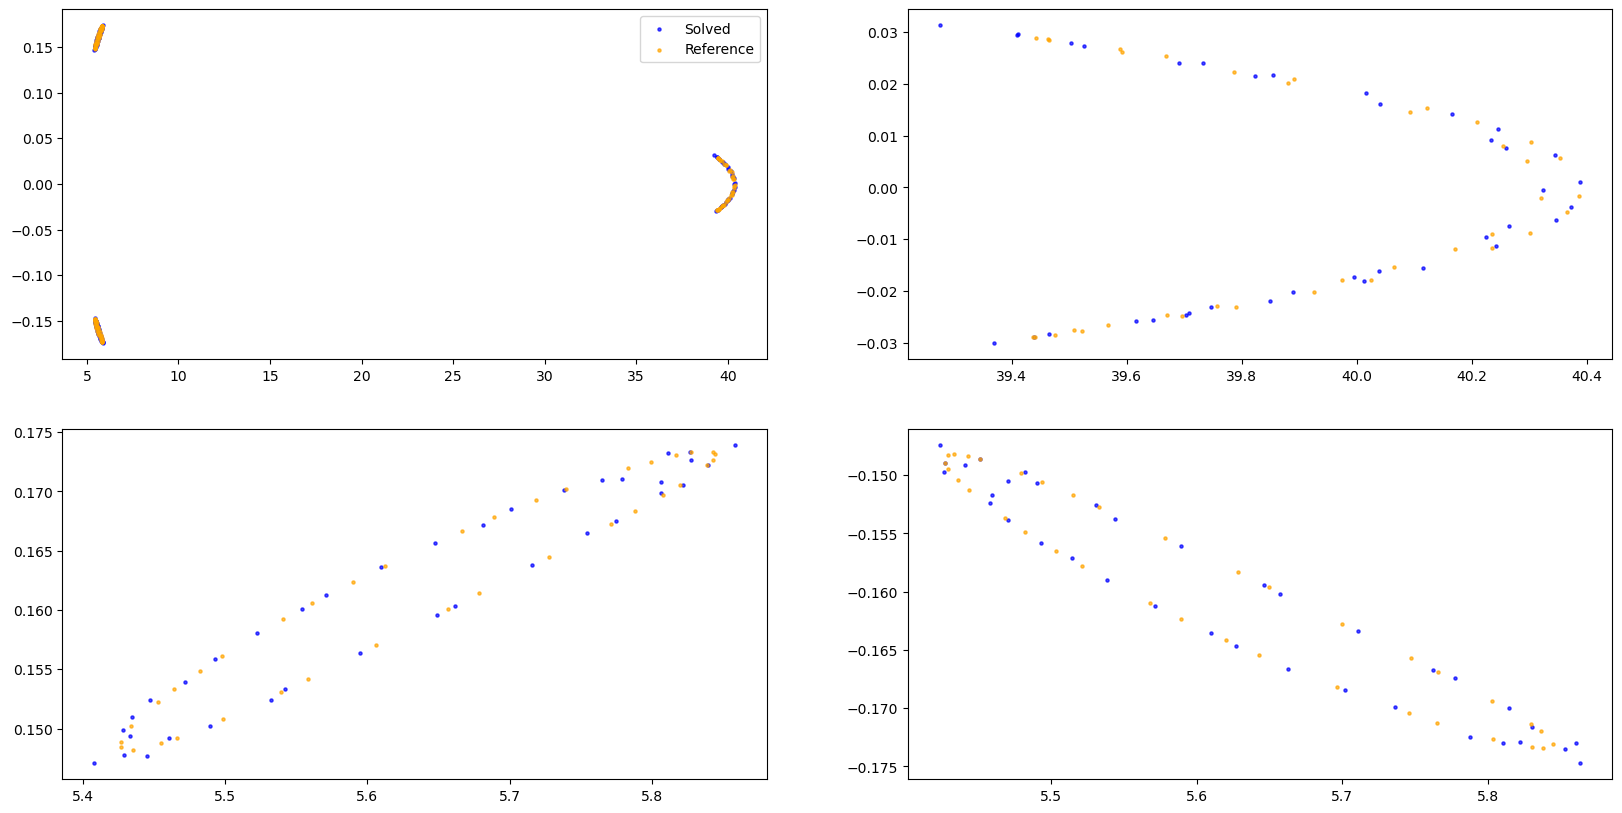

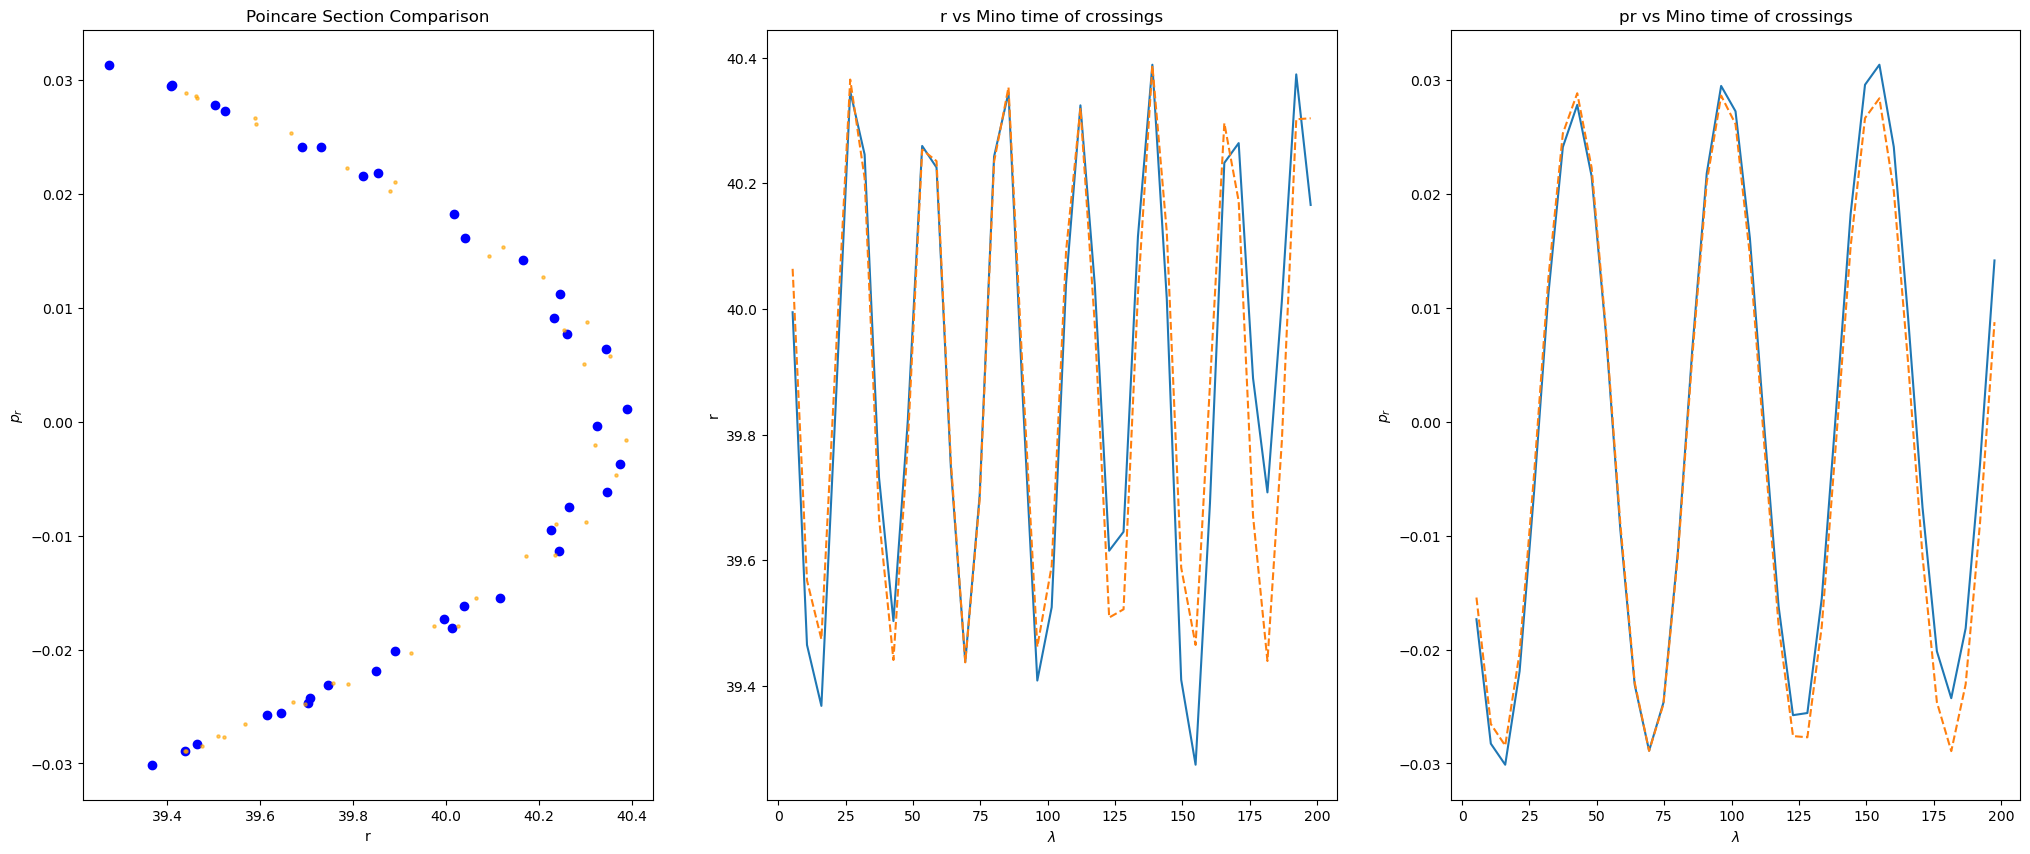

In [39]:
data_pcr = np.loadtxt("Poincare_Mino.dat")
mask = data_pcr[:, 0] <= 200
pr_lam = data_pcr[:, 0][mask]
pr_r = data_pcr[:, 1][mask]
pr_pr = data_pcr[:, 2][mask]

print(len(pr_lam))

i = 2
n = 3

pr_sliced = p_r[i::n]
p_pr_sliced = p_pr[i::n]
plam_sliced = p_lam[i::n]

j = i
pr_lam_s = pr_lam[j::n]
pr_r_s = pr_r[j::n]
pr_p_s = pr_pr[j::n]

plt.figure(figsize=(20, 10))

for i in (2, 3, 4):
    plt.subplot(2, 2, i)
    plt.scatter(p_r[i::3], p_pr[i::3],s=5, alpha = 0.7, color='blue', label='Solved')
    plt.scatter(pr_r[i::3], pr_pr[i::3],s=5, alpha = 0.7, color='orange', label='Reference')
    if(i == 1):
        plt.legend()

plt.subplot(2, 2, 1)
plt.scatter(p_r, p_pr, s=5, alpha=0.7, color='blue', label='Solved')
plt.scatter(pr_r, pr_pr, s=5, alpha=0.7, color='orange', label='Reference')
plt.legend()

plt.savefig('poincare_exp.png', dpi=300)

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 10))
ax1.scatter(pr_sliced, p_pr_sliced, alpha=1, color='blue')
ax1.scatter(pr_r_s, pr_p_s, alpha=0.6, s=5, color='orange')
ax1.set_xlabel('r')
ax1.set_ylabel(r'$p_r$')
ax1.set_title('Poincare Section Comparison')

ax2.plot(plam_sliced, pr_sliced)
ax2.plot(pr_lam_s, pr_r_s, linestyle='--')
ax2.set_xlabel(r'$\lambda$')
ax2.set_ylabel('r')
ax2.set_title('r vs Mino time of crossings')

ax3.plot(plam_sliced, p_pr_sliced)
ax3.plot(pr_lam_s, pr_p_s, linestyle='--')
ax3.set_xlabel(r'$\lambda$')
ax3.set_ylabel(r'$p_r$')
ax3.set_title('pr vs Mino time of crossings')

<>:48: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:48: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_13073/2765506274.py:48: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.title(r"Poincaré Section ($\theta = \pi/2$)")


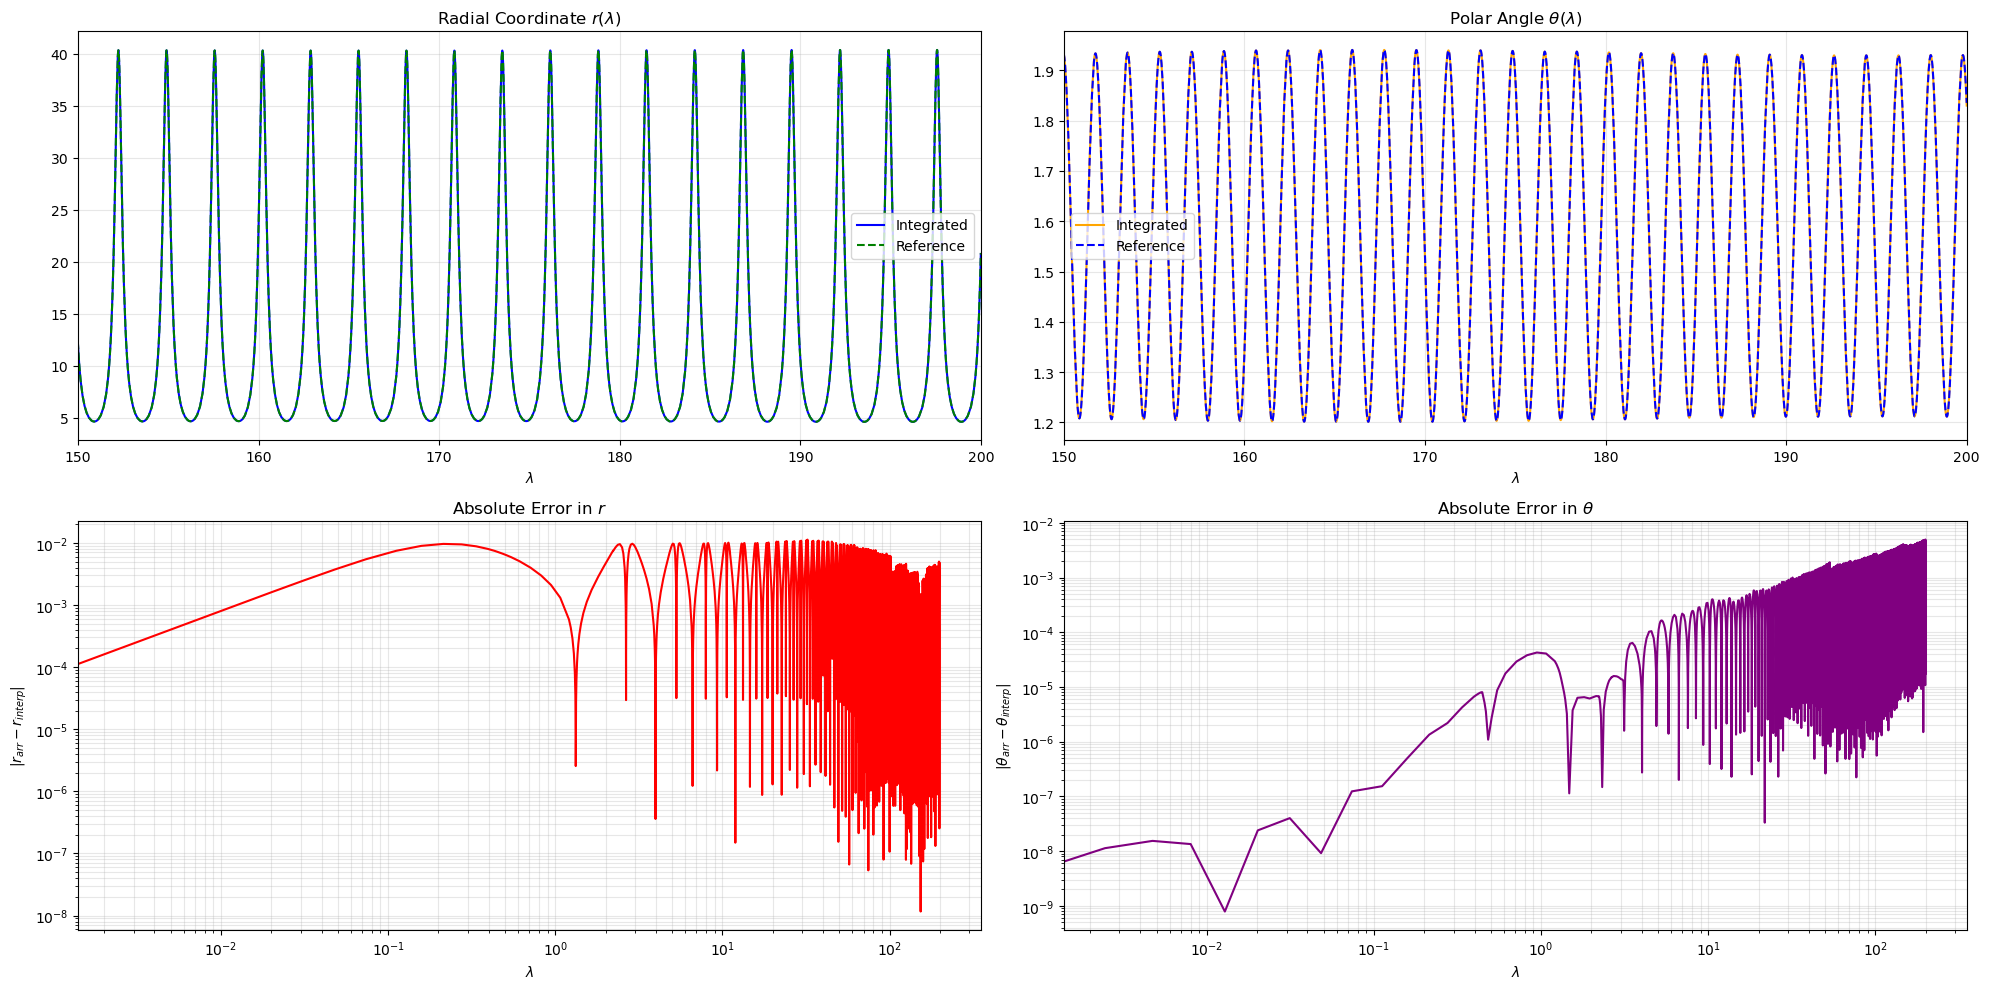

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

# --- 1. Radial Coordinate ---
plt.subplot(2, 2, 1)
r_interp = get_R(lam_arr)
plt.plot(lam_arr, r_arr, color='blue', label='Integrated')
plt.plot(lam_arr, r_interp, color='green', linestyle='--', label='Reference')
plt.title(r"Radial Coordinate $r(\lambda)$")
plt.xlabel(r"$\lambda$")
plt.grid(True, alpha=0.3)
plt.xlim(150, 200)
plt.legend()

# --- 2. Polar Angle ---
plt.subplot(2, 2, 2)
th_interp = get_th(lam_arr)
plt.plot(lam_arr, th_arr, color='orange', label='Integrated')
plt.plot(lam_arr, th_interp, color='blue', linestyle='--', label='Reference')
plt.title(r"Polar Angle $\theta(\lambda)$")
plt.xlabel(r"$\lambda$")
plt.grid(True, alpha=0.3)
plt.xlim(150, 200)
plt.legend()

# --- 3. Radial Interpolation Error (Log-Log) ---
plt.subplot(2, 2, 3)
plt.loglog(lam_arr, error_r, color='red')
plt.title(r"Absolute Error in $r$")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$|r_{arr} - r_{interp}|$")
plt.grid(True, alpha=0.3, which="both") 

# --- 4. Polar Interpolation Error (Log-Log) ---
plt.subplot(2, 2, 4)
plt.loglog(lam_arr, error_th, color='purple')
plt.title(r"Absolute Error in $\theta$")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$|\theta_{arr} - \theta_{interp}|$")
plt.grid(True, alpha=0.3, which="both")

'''# --- 5. Poincaré Section ---
plt.subplot(3, 2, 5)
# Assuming r_sec and pr_sec are your recorded crossings (e.g., at theta = pi/2)
plt.scatter(p_r, p_pr, color='black', s=2, alpha=0.7)
plt.title(r"Poincaré Section ($\theta = \pi/2$)")
plt.xlabel(r"$r$")
plt.ylabel(r"$p_r$")
plt.grid(True, alpha=0.3)


H_arr = calc_H(r_arr, th_arr, pr_arr, pth_arr, 0.98, 3.3, 0.5, 1.0, -0.001)
H2 = h2_full_calc(r_arr, th_arr, 0.98, 3.3, 0.5, get_K(lam_arr), -0.001)
H1 = -0.001*(3.3 - 2*0.5*0.98)
H_offset = H_arr - 0.5*(H1 + H2)

errorH = np.abs((-0.5 - H_offset)/H_offset)
# --- 6. Hamiltonian Error (Log-Log) ---
plt.subplot(3, 2, 6)
# Assuming H_err contains the relative error |(H - H_0) / H_0| computed along lam_arr
plt.loglog(lam_arr, errorH, color='teal')
plt.title(r"Relative Hamiltonian Error $\Delta H / H$")
plt.xlabel(r"$\lambda$")
plt.ylabel("Error")
plt.grid(True, alpha=0.3, which="both")'''

plt.tight_layout()
plt.show()

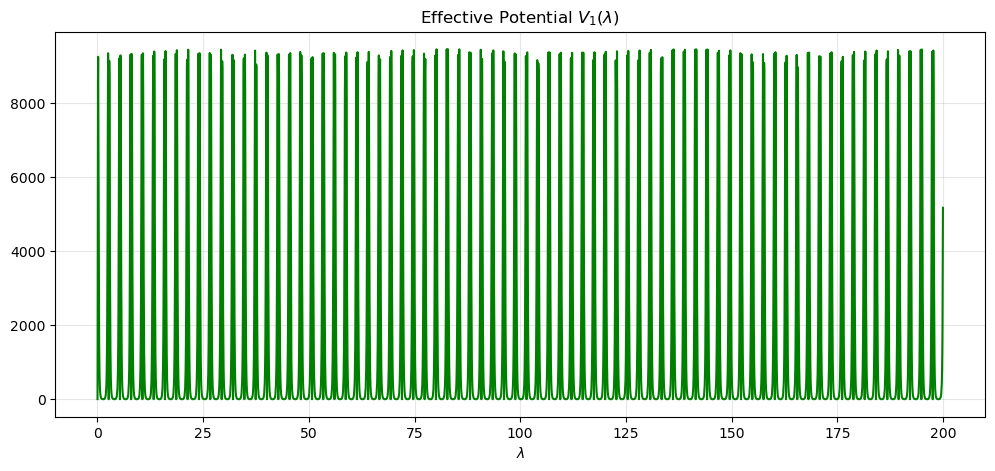

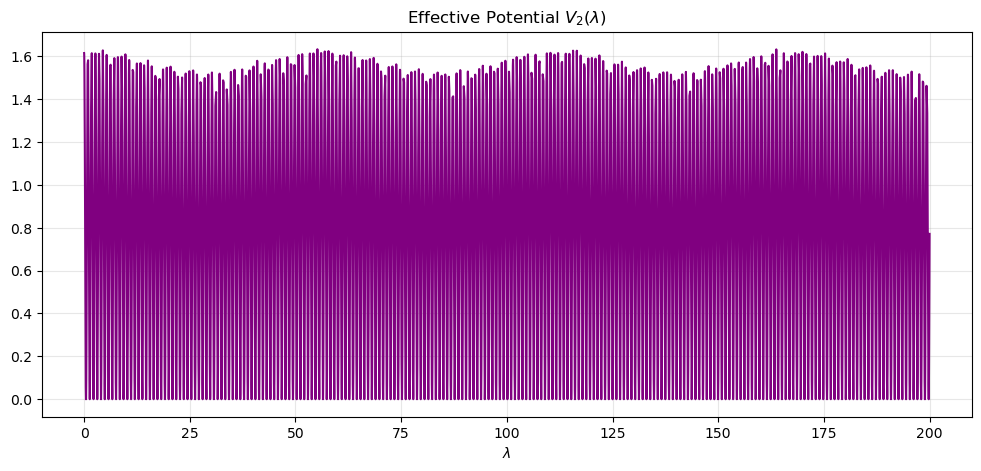

In [13]:
#Recomputing V1 and V2 from solved r and theta
V1_vals = np.array([rhs_potentials(r, th, E, Lz, a, get_K(lam), epsilon)[0] for r, th, lam in zip(r_arr, th_arr, lam_arr)])
V2_vals = np.array([rhs_potentials(r, th, E, Lz, a, get_K(lam), epsilon)[1] for r, th, lam in zip(r_arr, th_arr, lam_arr)])

plt.figure(figsize=(12, 5))
plt.plot(lam_arr, V1_vals, color='green')
plt.title(r"Effective Potential $V_1(\lambda)$")
plt.xlabel(r"$\lambda$")    
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(lam_arr, V2_vals, color='purple')  
plt.title(r"Effective Potential $V_2(\lambda)$")
plt.xlabel(r"$\lambda$")
plt.grid(True, alpha=0.3)
plt.show()



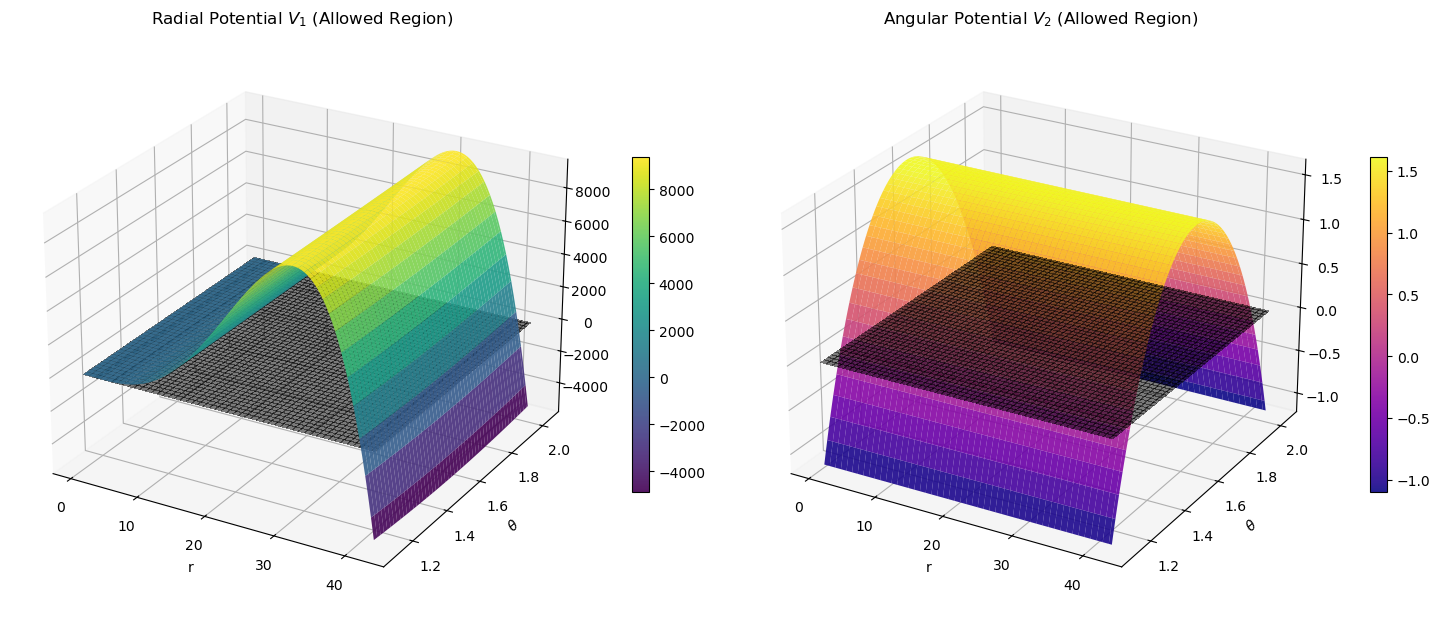

Roots:
r: [2.3407833523562194, 4.687737449658578, 40.32410407443721]
 theta: [1.2033308112094943, 1.9382618423802989]
V1 at r_initial = 40.323: 2.604585194028914


In [14]:
#V1 and V2 surface plots and roots
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def v1_root_func(r_val):
    v1, _ = rhs_potentials(r_val, np.pi/2, E, Lz, a, get_K(lam_data[0]), epsilon)
    return v1

# For V2, we find roots in 'theta' at a fixed r (e.g., current r)
def v2_root_func(th_val):
    _, v2 = rhs_potentials(r_arr[0], th_val, E, Lz, a, get_K(lam_data[0]), epsilon)
    return v2

def find_all_roots(func, start, end, pts=500):
    x = np.linspace(start, end, pts)
    # Use list comprehension to handle potential array/scalar issues from lambdify
    y = [func(xi) for xi in x]
    roots = []
    for i in range(len(x)-1):
        if y[i] * y[i+1] < 0:
            roots.append(brentq(func, x[i], x[i+1]))
    return roots

# 3. Calculate the roots
# Radial search from horizon to a safe upper bound
r_roots = find_all_roots(v1_root_func, 2.01, 100)
# Angular search from pole to pole
th_roots = find_all_roots(v2_root_func, 0.01, np.pi - 0.01)

Delta_r = 2.0
Delta_th = 0.1
if len(r_roots) >= 2 and len(th_roots) >= 2:
    # Use the min/max found roots to define the plot domain
    r_min, r_max = min(r_roots) - Delta_r, max(r_roots) + Delta_r
    th_min, th_max = min(th_roots) - Delta_th, max(th_roots) + Delta_th
    
    # 4. Create the confined grid
    r_grid = np.linspace(r_min, r_max, 100)
    th_grid = np.linspace(th_min, th_max, 100)
    R, TH = np.meshgrid(r_grid, th_grid)
    
    V1_grid, V2_grid = rhs_potentials(R, TH, E, Lz, a, get_K(lam_data[0]), epsilon)
        

    # 5. Plotting
    fig = plt.figure(figsize=(15, 7))
    
    # V1 Plot
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.view_init(elev=25, azim=-60)
    surf1 = ax1.plot_surface(R, TH, V1_grid, cmap='viridis', edgecolor='none', alpha=0.9)
    ax1.plot_surface(R, TH, np.zeros_like(R), cmap='gray', edgecolor='none', alpha=0.5, antialiased=False)  
    ax1.set_title(r'Radial Potential $V_1$ (Allowed Region)')
    ax1.set_xlabel('r'); ax1.set_ylabel(r'$\theta$')
    fig.colorbar(surf1, ax=ax1, shrink=0.5)
    ax1.contour(R, TH, V1_grid, levels=[0], colors='black', linestyles='dashed')
    # V2 Plot
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.view_init(elev=25, azim=-60)
    surf2 = ax2.plot_surface(R, TH, V2_grid, cmap='plasma', edgecolor='none', alpha=0.9)
    ax2.plot_surface(R, TH, np.zeros_like(R), cmap='gray', edgecolor='none', alpha=0.5, antialiased=False)  
    ax2.set_title(r'Angular Potential $V_2$ (Allowed Region)')
    ax2.set_xlabel('r'); ax2.set_ylabel(r'$\theta$')
    fig.colorbar(surf2, ax=ax2, shrink=0.5)
    ax2.contour(R, TH, V2_grid, levels=[0], colors='black', linestyles='dashed')

    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find sufficient roots. r_roots: {r_roots}, th_roots: {th_roots}")
    
print(f"Roots:\nr: {r_roots}\n theta: {th_roots}")

r_initial = 40.323
print(f"V1 at r_initial = {r_initial:.3f}: {rhs_potentials(r_initial, np.pi/2, E, Lz, a, get_K(lam_data[0]), epsilon)[0]}")

sd 8.976720648007735e-05
mean error: 0.010979311238182927


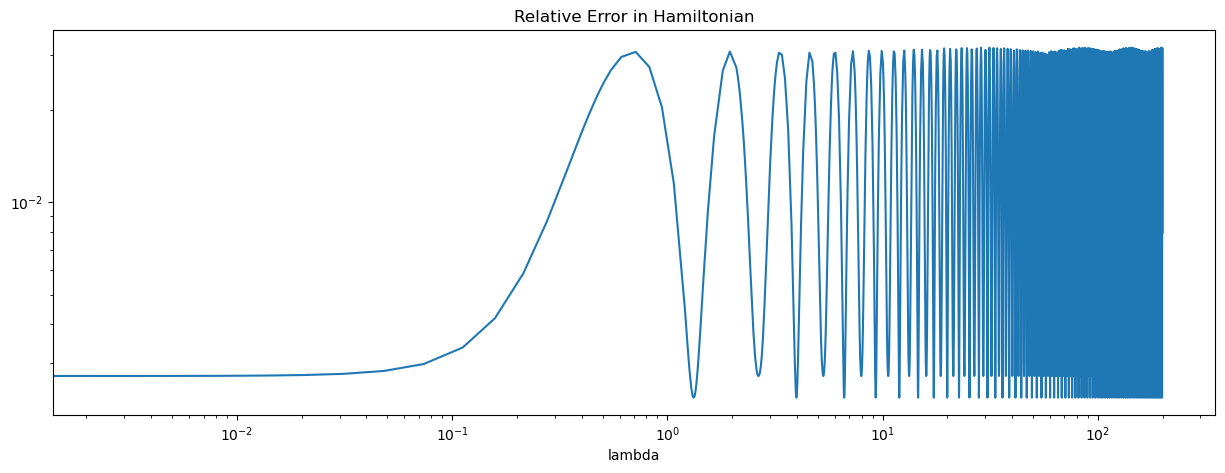

In [15]:

H_arr = calc_H(r_arr, th_arr, pr_arr, pth_arr, 0.98, 3.3, 0.5, 1.0, -0.001)
H2 = h2_full_calc(r_arr, th_arr, 0.98, 3.3, 0.5, get_K(lam_arr), -0.001)
H1 = -0.001*(3.3 - 2*0.5*0.98)
H_offset = H_arr - 0.5*(H1 + H2)

error = np.abs((-0.5 - H_offset)/H_offset)

plt.figure(figsize=(15, 5))
plt.plot(lam_arr, error)
plt.xscale('log')
plt.yscale('log')
plt.title('Relative Error in Hamiltonian')
plt.xlabel(r'lambda')

sd = np.mean(error**2) - (np.mean(error))**2
print('sd', sd)

print('mean error:', np.mean(error))


In [16]:
#Grid Search Loop
import numpy as np
import itertools
from joblib import Parallel, delayed

tcase = np.logspace(-6, -12, 6)
combinations = list(itertools.product(tcase, tcase, tcase))

def run_single_case(idx, proxy_eps, rtol, atol, initial_s, params_p, eps_val):
    try:
        result = geodesic_integrator(
            initial_s,
            initial_signs=[-1, 1],
            lam_range=[0, 1000],
            params=params_p,
            epsilon=eps_val,
            proxy_eps=proxy_eps,
            rtol=rtol,
            atol=atol
        )
        
        # Calculate the error
        error = np.abs(result['r'] - get_R(result['lambda'])) / result['r']
        rmse = np.sqrt(np.mean(error**2))
        
        return {
            'index': idx, 
            'proxy_eps': proxy_eps, 
            'rtol': rtol, 
            'atol': atol, 
            'rmse': rmse
        }
    except Exception as e:
        return {'index': idx, 'error': str(e)}

# Joblib Multithread exec
print("Index | proxy_eps      | rtol           | atol           | rmse")
print("-" * 75)

results_big = []

results_generator = Parallel(n_jobs=8, return_as='generator')(
    delayed(run_single_case)(idx + 1, p, r, a, init_state, phys_params, eps)
    for idx, (p, r, a) in enumerate(combinations)
)

for res in results_generator:
    if 'error' not in res:
        print(f"{res['index']:<5} | {res['proxy_eps']:<14.1e} | {res['rtol']:<14.1e} | {res['atol']:<14.1e} | {res['rmse']:.5e}")
        results_big.append(res)
    else:
        print(f"{res['index']:<5} | FAILED: {res['error']}")

rmse, idx, atol, rtol, proxy_ep = [], [], [], [], [] 
for i in range(216): 
    rmse.append(results_big[i]['rmse'])
    idx.append(results_big[i]['index'])
    atol.append(results_big[i]['atol'])
    rtol.append(results_big[i]['rtol'])
    proxy_ep.append(results_big[i]['proxy_eps'])

# 1. Extract the full dictionaries that meet the condition
best_results = [res for res in results_big if 'rmse' in res and res['rmse'] < 5e-2]

# 2. Extract just the indexes into a separate list (if needed)
best_indexes = [res['index'] for res in best_results]

# Print the filtered results sorted by lowest RMSE
print(f"Found {len(best_results)} configurations with RMSE < 5e-2:\n")

# Optional: Sort them from lowest error to highest before printing
best_results_sorted = sorted(best_results, key=lambda x: x['rmse'])

for res in best_results_sorted:
    print(f"Index: {res['index']:<5} | proxy_eps: {res['proxy_eps']:<10.1e} | rtol: {res['rtol']:<10.1e} | atol: {res['atol']:<10.1e} | rmse: {res['rmse']:.5e}")

import matplotlib.pyplot as plt
import numpy as np

# Choose how many of the top results you want to plot (e.g., Top 5)
# 'best_results_sorted' is the list we generated in the previous step
top_n = min(5, len(best_results_sorted))

plt.figure(figsize=(14, 7))

print(f"Re-running the top {top_n} configurations for plotting...")

for i in range(top_n):
    config = best_results_sorted[i]
    
    # 1. Re-run the integration for this specific winning configuration
    # Note: We run it up to lambda=100 because that is where your reference get_R() is valid
    result = geodesic_integrator(
        init_state,
        initial_signs=[-1, 1],
        lam_range=[0, 1000], 
        params=phys_params,
        epsilon=eps,
        proxy_eps=config['proxy_eps'],
        rtol=config['rtol'],
        atol=config['atol']
    )
    
    # 2. Extract arrays and recalculate the relative error
    lam_arr = result['lambda']
    r_arr = result['r']
    ref_r = get_R(lam_arr) # Your reference analytical/interpolated function
    
    error = np.abs(r_arr - ref_r) / r_arr
    
    # 3. Plot using a log scale for the Y-axis (since errors span multiple magnitudes)
    label_str = f"proxy={config['proxy_eps']:.1e} | rtol={config['rtol']:.1e} | atol={config['atol']:.1e} (RMSE: {config['rmse']:.1e})"
    plt.semilogy(lam_arr, error, label=label_str, alpha=0.8, linewidth=1.5)

# 4. Formatting the plot
plt.title("Relative Error vs Mino Time (Top Hyperparameter Configurations)", fontsize=14)
plt.xlabel(r"Mino Time ($\lambda$)", fontsize=12)
plt.ylabel("Relative Error", fontsize=12)

# Grid lines for both major and minor ticks on the log scale
plt.grid(True, which="major", linestyle="-", alpha=0.6)
plt.grid(True, which="minor", linestyle=":", alpha=0.4)

# Place the legend outside the plot so it doesn't cover the data
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()


ModuleNotFoundError: No module named 'joblib'